<a href="https://colab.research.google.com/github/thaiyalvishu97/MyProjects/blob/main/Project_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project 14 - Uber Pickups Cluster

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("Uber-Jan-Feb-FOIL.csv")

In [3]:
df.isnull().sum()

,0
dispatching_base_number,0
date,0
active_vehicles,0
trips,0


In [4]:
X = df[["active_vehicles","trips"]]

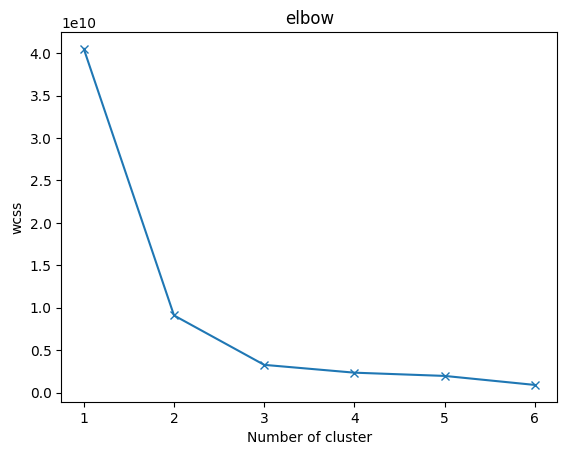

In [5]:
wcss=[]
for k in range(1,7):
  km = KMeans(n_clusters=k,random_state=42)
  km.fit(X)
  wcss.append(km.inertia_)
plt.plot(range(1,7),wcss,marker='x')
plt.title("elbow")
plt.xlabel("Number of cluster")
plt.ylabel("wcss")
plt.show()

In [6]:
model = KMeans(n_clusters=3,random_state=0)

In [7]:
df["cluster"]= model.fit_predict(X)

In [8]:
centroids = model.cluster_centers_

In [9]:
print(pd.DataFrame(centroids,columns=X.columns))

   active_vehicles         trips
0       341.554688   2605.914063
1      3764.129630  33725.370370
2      1254.941860  11485.482558


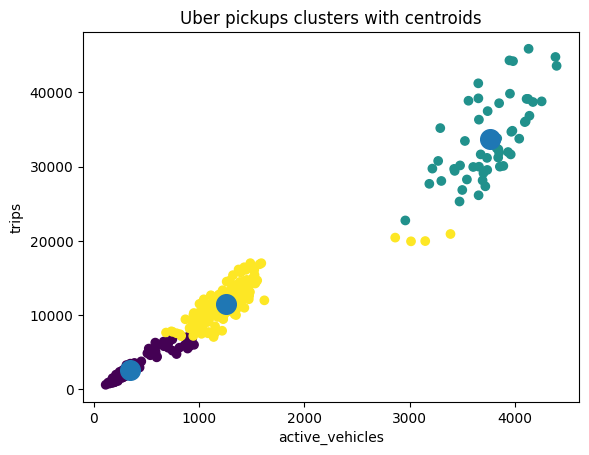

In [10]:
plt.scatter(df["active_vehicles"],df["trips"],c=df["cluster"])
plt.scatter(centroids[:,0],centroids[:,1],marker='o',s=200)
plt.xlabel("active_vehicles")
plt.ylabel("trips")
plt.title("Uber pickups clusters with centroids")
plt.show()